# Mini Project 1 — Analisis Diabetes Pima Indians

Nama: Xavier Theofilus Munthe

Dataset: [Kaggle — Diabetes Dataset (mathchi)](https://www.kaggle.com/datasets/mathchi/diabetes-data-set)
Sumber Asli: National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)

*Background*

Diabetes mellitus adalah penyakit metabolik kronis yang ditandai dengan kadar glukosa darah tinggi. Deteksi dini sangat penting untuk mencegah komplikasi serius seperti gagal ginjal dan penyakit jantung. Dataset ini mencatat kondisi klinis 768 wanita keturunan Pima Indian berusia minimal 21 tahun, sebuah populasi yang dikenal memiliki prevalensi diabetes tipe 2 jauh di atas rata-rata.

*Problem Statement*

Faktor klinis apa saja yang paling membedakan pasien diabetes dari yang tidak diabetes pada 768 wanita Pima Indian?

## *Setup*

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
})

## *Data Cleansing*

In [10]:
df = pd.read_csv('diabetes_kaggle.csv')

print(f"Dimensi dataset : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Duplikat        : {df.duplicated().sum()}")
print(f"Missing values  : {df.isnull().sum().sum()}")
df.head()

Dimensi dataset : 768 baris x 9 kolom
Duplikat        : 0
Missing values  : 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,84,51,10,17,29.4,0.336,29,0
1,6,145,120,28,90,27.5,0.720,21,0
2,5,103,79,41,201,40.1,0.542,24,0
3,4,105,113,22,14,32.8,0.386,46,0
4,3,113,100,18,196,52.1,0.301,40,1


Kolom SkinThickness dan Insulin tidak digunakan -> karena nilai 0, merupakan nilai klinis yang valid. 
Secara biologis, tidak mungkin seseorang memiliki ketebalan kulit atau kadar insulin 0. 
Nilai tersebut merupakann data yang tidak tercatat, bukan kondisi sesungguhnya. 
Kedua kolom -> status 'Tidak Diketahui' dan nilai 0 dikonversi ke NaN, 

In [11]:
kolom_digunakan = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print("Jumlah nilai 0 pada kolom yang digunakan:")
nol = (df[kolom_digunakan] == 0).sum()
pct = (df[kolom_digunakan] == 0).mean() * 100
ringkasan = pd.DataFrame({'Jumlah Nol': nol, 'Persentase (%)': pct.round(1)})
print(ringkasan)

Jumlah nilai 0 pada kolom yang digunakan:
                          Jumlah Nol  Persentase (%)
Pregnancies                      117            15.2
Glucose                            0             0.0
BloodPressure                      0             0.0
BMI                                0             0.0
DiabetesPedigreeFunction           0             0.0
Age                                0             0.0


In [12]:
df_clean = df.copy()

kolom_flag = ['SkinThickness', 'Insulin']
for col in kolom_flag:
    flag_col = col + '_Status'
    df_clean[flag_col] = df_clean[col].apply(
        lambda x: 'Tidak Diketahui' if x == 0 else 'Diketahui'
    )
    df_clean[col] = df_clean[col].replace(0, np.nan)

df_clean['Diagnosis'] = df_clean['Outcome'].map({0: 'Tidak Diabetes', 1: 'Diabetes'})

print("Status data SkinThickness:")
print(df_clean['SkinThickness_Status'].value_counts())
print()
print("Status data Insulin:")
print(df_clean['Insulin_Status'].value_counts())

Status data SkinThickness:
SkinThickness_Status
Diketahui          687
Tidak Diketahui     81
Name: count, dtype: int64

Status data Insulin:
Insulin_Status
Diketahui          573
Tidak Diketahui    195
Name: count, dtype: int64


In [13]:
def kategori_bmi(b):
    if pd.isna(b): return 'Tidak Diketahui'
    if b < 18.5:   return 'Kurus'
    elif b < 25:   return 'Normal'
    elif b < 30:   return 'Gemuk'
    else:          return 'Obesitas'

def kelompok_usia(age):
    if age < 30:   return '21-29'
    elif age < 40: return '30-39'
    elif age < 50: return '40-49'
    elif age < 60: return '50-59'
    else:          return '60+'

df_clean['Kategori_BMI']  = df_clean['BMI'].apply(kategori_bmi)
df_clean['Kelompok_Usia'] = df_clean['Age'].apply(kelompok_usia)

print(f"Dataset siap digunakan: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
df_clean.head(3)

Dataset siap digunakan: 768 baris, 14 kolom


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,SkinThickness_Status,Insulin_Status,Diagnosis,Kategori_BMI,Kelompok_Usia
0,4,84,51,10.0,17.0,29.4,0.336,29,0,Diketahui,Diketahui,Tidak Diabetes,Gemuk,21-29
1,6,145,120,28.0,90.0,27.5,0.720,21,0,Diketahui,Diketahui,Tidak Diabetes,Gemuk,21-29
2,5,103,79,41.0,201.0,40.1,0.542,24,0,Diketahui,Diketahui,Tidak Diabetes,Obesitas,21-29


## *Statistika Deskriptif*
Glucose, BloodPressure, BMI, DiabetesPedigreeFunction, Age, dan Pregnancies

In [14]:
kolom_analisis = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']
df_clean[kolom_analisis].describe().round(2)

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
count,768.0,768.00,768.00,768.00,768.00,768.00
mean,4.6,120.00,68.88,31.82,0.49,33.66
std,4.3,30.29,19.22,7.95,0.30,9.94
min,0.0,23.00,8.00,2.50,0.08,21.00
25%,1.0,99.00,56.00,26.18,0.26,25.00
50%,3.0,120.00,69.00,31.80,0.47,33.00
75%,7.0,138.00,81.25,37.40,0.70,40.00
max,17.0,199.00,122.00,52.50,1.46,66.00


In [15]:
hasil = []

for c in kolom_analisis:
    s   = df_clean[c].dropna()
    Q1  = s.quantile(0.25)
    Q3  = s.quantile(0.75)
    IQR = Q3 - Q1
    hasil.append({
        'Variabel' : c,
        'Mean'     : round(s.mean(), 2),
        'Median'   : round(s.median(), 2),
        'Std Dev'  : round(s.std(), 2),
        'Min'      : round(s.min(), 2),
        'Max'      : round(s.max(), 2),
        'IQR'      : round(IQR, 2),
        'Skewness' : round(s.skew(), 3),
    })

df_stats = pd.DataFrame(hasil).set_index('Variabel')
df_stats

,Mean,Median,Std Dev,Min,Max,IQR,Skewness
Variabel,,,,,,,
Pregnancies,4.60,3.00,4.30,0.00,17.00,6.00,1.027
Glucose,120.00,120.00,30.29,23.00,199.00,39.00,0.069
BloodPressure,68.88,69.00,19.22,8.00,122.00,25.25,-0.019
BMI,31.82,31.80,7.95,2.50,52.50,11.22,-0.069
DiabetesPedigreeFunction,0.49,0.47,0.30,0.08,1.46,0.44,0.428
Age,33.66,33.00,9.94,21.00,66.00,15.00,0.606


Glukosa memiliki rata-rata 119.98 mg/dL dengan median 120 mg/dL, distribusinya mendekati simetris. 
BMI rata-rata 31.99 sudah masuk kategori obesitas. DiabetesPedigreeFunction memiliki skewness positif yang cukup tinggi (1.920) artinya sebagian besar nilai berkumpul di bawah dengan sejumlah kecil nilai ekstrem tinggi. Usia memiliki range lebar dari 21 hingga 66 tahun -> skewness positif, berartio lebih banyak pasien muda

## *Visualisasi Data*

### *Grafik 1 — Distribusi Pasien Berdasarkan Diagnosis*

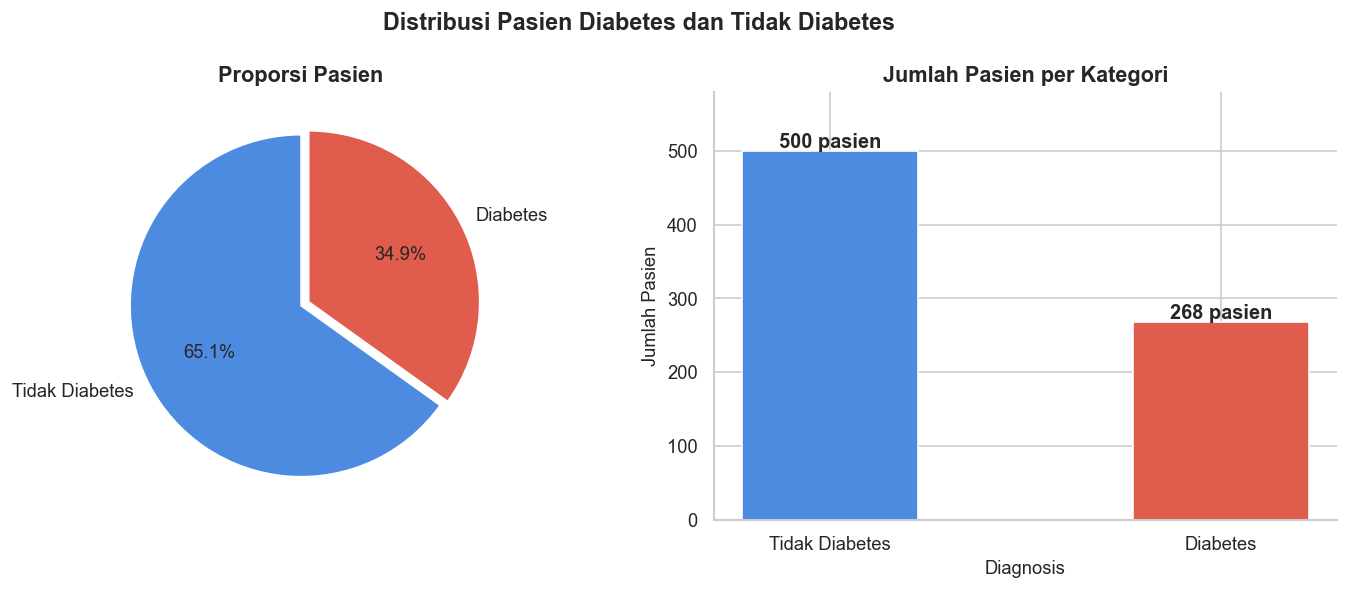

In [16]:
jumlah = df_clean['Diagnosis'].value_counts()
warna  = ['#4C8BE0', '#E05C4C']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    jumlah.values, labels=jumlah.index, autopct='%1.1f%%',
    colors=warna, startangle=90, explode=(0, 0.05),
    textprops={'fontsize': 11}
)
axes[0].set_title('Proporsi Pasien')

bar = axes[1].bar(jumlah.index, jumlah.values, color=warna, width=0.45, edgecolor='white')
for b, v in zip(bar, jumlah.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(v) + ' pasien', ha='center', fontweight='bold')
axes[1].set_title('Jumlah Pasien per Kategori')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].set_ylim(0, 580)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Distribusi Pasien Diabetes dan Tidak Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dataset terdiri dari 500 pasien Tidak Diabetes (65.1%) dan 268 pasien Diabetes (34.9%). Rasionya sekitar 1.9 berbanding 1, jadi dataset tidak seimbang. Untuk analisis deskriptif dan inferensial, proporsi kelas minoritas sebesar 34.9% cukup representatif. 

### *Grafik 2 — Distribusi Kadar Glukosa per Kelompok Diagnosis*

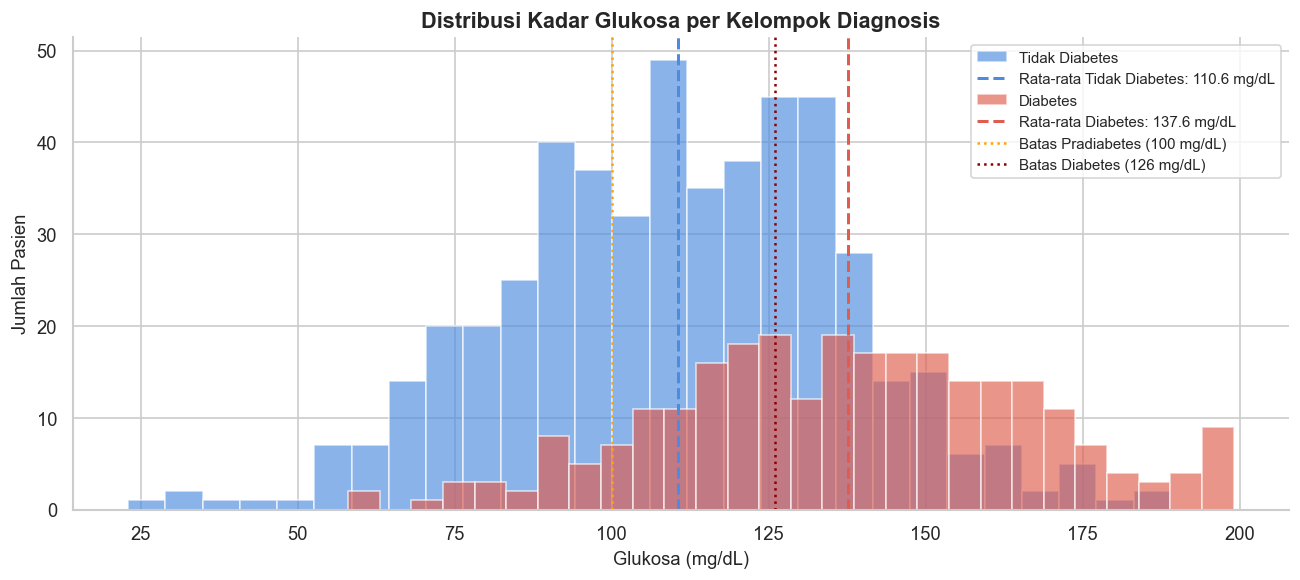

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

for label, warna in [('Tidak Diabetes', '#4C8BE0'), ('Diabetes', '#E05C4C')]:
    data = df_clean[df_clean['Diagnosis'] == label]['Glucose'].dropna()
    ax.hist(data, bins=28, alpha=0.65, color=warna, label=label, edgecolor='white')
    ax.axvline(data.mean(), color=warna, linestyle='--', linewidth=1.8,
               label=f'Rata-rata {label}: {data.mean():.1f} mg/dL')

ax.axvline(100, color='orange', linestyle=':', linewidth=1.5, label='Batas Pradiabetes (100 mg/dL)')
ax.axvline(126, color='darkred', linestyle=':', linewidth=1.5, label='Batas Diabetes (126 mg/dL)')

ax.set_title('Distribusi Kadar Glukosa per Kelompok Diagnosis')
ax.set_xlabel('Glukosa (mg/dL)')
ax.set_ylabel('Jumlah Pasien')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

Pasien Tidak Diabetes memiliki rata-rata glukosa 110.6 mg/dL, sementara pasien Diabetes rata-rata 137.6 mg/dL, selisihnya 27 mg/dL. 
Distribusi Tidak Diabetes terpusat dan mendekati simetris. Distribusi Diabetes lebih tersebar ke kanan dengan banyak pasien melampaui batas 126 mg/dL. Grafik menegaskan bahwa kadar glukosa adalah indikator pembeda paling jelas antara kedua kelompok dalam dataset ini.

### *Grafik 3 — Boxplot Variabel Utama per Diagnosis*

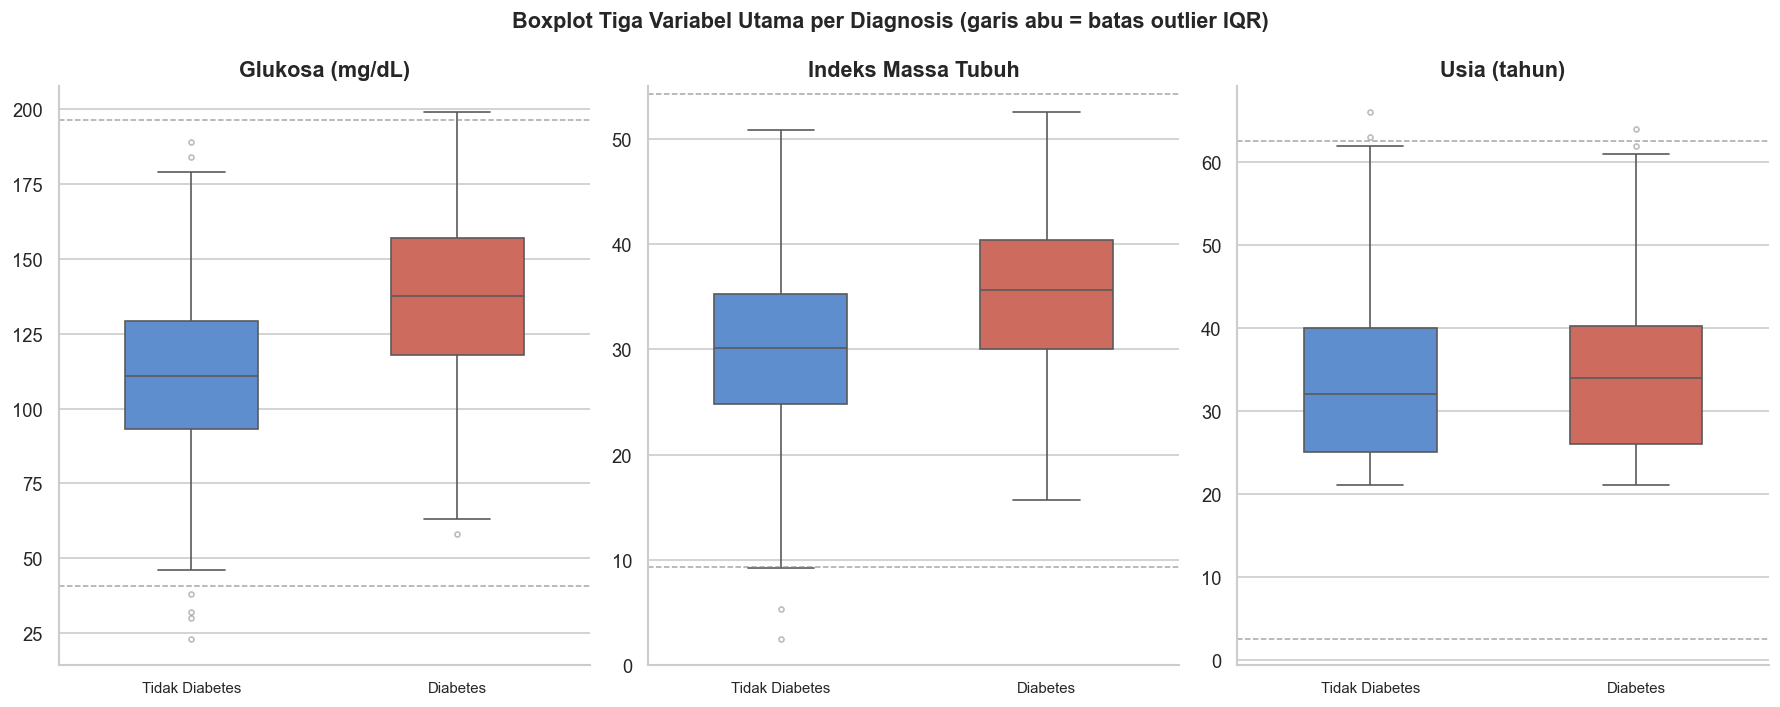

In [18]:
palet = {'Tidak Diabetes': '#4C8BE0', 'Diabetes': '#E05C4C'}
label_map = {
    'Glucose': 'Glukosa (mg/dL)',
    'BMI': 'Indeks Massa Tubuh',
    'Age': 'Usia (tahun)'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(['Glucose', 'BMI', 'Age']):
    sns.boxplot(
        data=df_clean, x='Diagnosis', y=col,
        palette=palet, ax=axes[i], width=0.5,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    Q1  = df_clean[col].dropna().quantile(0.25)
    Q3  = df_clean[col].dropna().quantile(0.75)
    IQR = Q3 - Q1
    axes[i].axhline(Q3 + 1.5*IQR, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
    axes[i].axhline(max(Q1 - 1.5*IQR, 0), color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
    axes[i].set_title(label_map[col])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Boxplot Tiga Variabel Utama per Diagnosis (garis abu = batas outlier IQR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Glukosa menunjukkan pemisahan paling jelas. Median pasien Tidak Diabetes berada di 111 mg/dL dengan IQR 93 hingga 129.25, sementara median pasien Diabetes di 137.5 mg/dL dengan IQR 118 hingga 157. Kotak keduanya hampir tidak tumpang tindih.

BMI pasien Tidak Diabetes memiliki median 30.1 dengan IQR 24.8 hingga 35.2, sedangkan pasien Diabetes median 35.7 dengan IQR 30.1 hingga 40.4. Perbedaannya nyata meskipun kotak masih sedikit tumpang tindih.

Usia menunjukkan perbedaan paling kecil. Median Tidak Diabetes 32 tahun, Diabetes 34 tahun, dan kotak IQR keduanya hampir sepenuhnya bertumpang tindih. Ini mengonfirmasi usia bukan pembeda yang kuat secara individual.

### Grafik 4 — Tingkat Diabetes per Kategori BMI dan Kelompok Usia

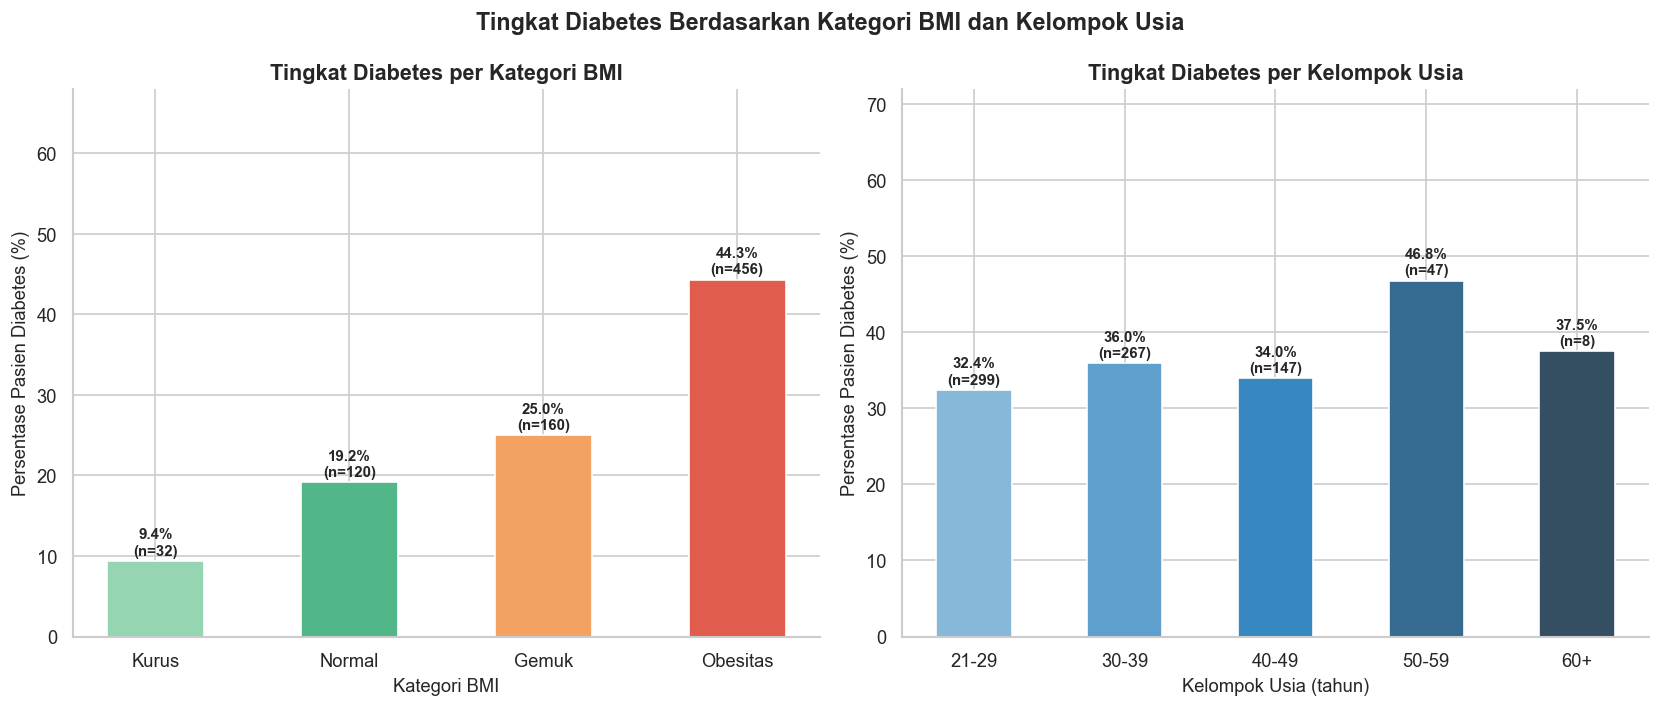

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

urutan_bmi = ['Kurus', 'Normal', 'Gemuk', 'Obesitas']
warna_bmi  = ['#95D5B2', '#52B788', '#F4A261', '#E05C4C']
df_bmi_valid = df_clean[df_clean['Kategori_BMI'] != 'Tidak Diketahui']
rate_bmi = df_bmi_valid.groupby('Kategori_BMI')['Outcome'].mean().reindex(urutan_bmi) * 100
n_bmi    = df_bmi_valid.groupby('Kategori_BMI')['Outcome'].count().reindex(urutan_bmi)

bar1 = axes[0].bar(rate_bmi.index, rate_bmi.values, color=warna_bmi,
                   edgecolor='white', width=0.5)
for b, v, n in zip(bar1, rate_bmi.values, n_bmi.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                 f'{v:.1f}%\n(n={n})', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Tingkat Diabetes per Kategori BMI')
axes[0].set_xlabel('Kategori BMI')
axes[0].set_ylabel('Persentase Pasien Diabetes (%)')
axes[0].set_ylim(0, 68)
axes[0].spines[['top','right']].set_visible(False)

urutan_usia = ['21-29', '30-39', '40-49', '50-59', '60+']
rate_usia   = df_clean.groupby('Kelompok_Usia')['Outcome'].mean().reindex(urutan_usia) * 100
n_usia      = df_clean.groupby('Kelompok_Usia')['Outcome'].count().reindex(urutan_usia)
warna_usia  = sns.color_palette('Blues_d', len(urutan_usia))

bar2 = axes[1].bar(rate_usia.index, rate_usia.values, color=warna_usia,
                   edgecolor='white', width=0.5)
for b, v, n in zip(bar2, rate_usia.values, n_usia.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                 f'{v:.1f}%\n(n={n})', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Tingkat Diabetes per Kelompok Usia')
axes[1].set_xlabel('Kelompok Usia (tahun)')
axes[1].set_ylabel('Persentase Pasien Diabetes (%)')
axes[1].set_ylim(0, 72)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Tingkat Diabetes Berdasarkan Kategori BMI dan Kelompok Usia',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Pola pada kategori BMI sangat konsisten. Kelompok Kurus hanya 9.4% pasiennya terdiagnosis diabetes (n=32), Normal 19.2% (n=120), Gemuk 25.0% (n=160), dan Obesitas mencapai 44.3% (n=456), hampir lima kali lipat lebih tinggi dari kelompok Kurus.

Pada kelompok usia, pola tidak sepenuhnya linear. Kelompok 21-29 tahun memiliki tingkat 32.4% (n=299), 30-39 tahun 36.0% (n=267), 40-49 tahun 34.0% (n=147), 50-59 tahun mencapai puncaknya 46.8% (n=47), lalu 60 ke atas 37.5% (n=8). Kelompok 60+ memiliki sampel sangat kecil sehingga estimasinya kurang stabil.

### Grafik 5 — Heatmap Korelasi Pearson Antar Variabel

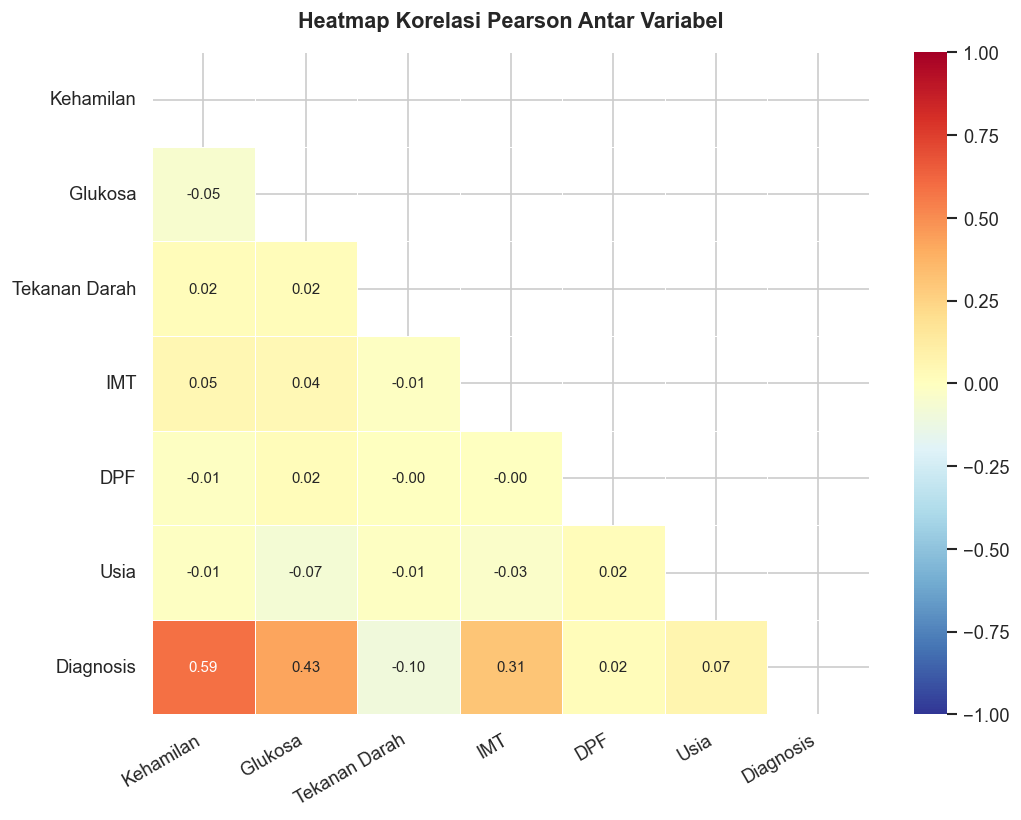

In [20]:
kolom_label = {
    'Pregnancies'             : 'Kehamilan',
    'Glucose'                 : 'Glukosa',
    'BloodPressure'           : 'Tekanan Darah',
    'BMI'                     : 'IMT',
    'DiabetesPedigreeFunction': 'DPF',
    'Age'                     : 'Usia',
    'Outcome'                 : 'Diagnosis',
}

df_corr = df_clean[list(kolom_label.keys())].copy()
df_corr.columns = list(kolom_label.values())

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
    mask=mask, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Heatmap Korelasi Pearson Antar Variabel', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
corr_diag = corr['Diagnosis'].drop('Diagnosis').sort_values(key=abs, ascending=False)
print("Korelasi terhadap Diagnosis (diurutkan dari terkuat):")
print(corr_diag.round(4).to_string())

Korelasi terhadap Diagnosis (diurutkan dari terkuat):
Kehamilan        0.5929
Glukosa          0.4252
IMT              0.3096
Tekanan Darah   -0.0961
Usia             0.0682
DPF              0.0209


Dari heatmap, Kehamilan memiliki korelasi tertinggi terhadap Diagnosis (r = 0.59), diikuti Glukosa (r = 0.43), IMT (r = 0.31), lalu Usia (r = 0.07), Tekanan Darah (r = -0.10), dan DPF (r = 0.02) yang sangat lemah.

Korelasi antar fitur tertinggi ada di pasangan Glukosa dan Usia sebesar -0.07, artinya tidak ada masalah multikolinearitas. Semua pasangan variabel berada jauh di bawah ambang 0.7, sehingga variabel-variabel ini bisa digunakan bersama dalam model prediksi tanpa risiko redundansi yang serius.

### Grafik 6 — Scatter Plot Glukosa vs BMI

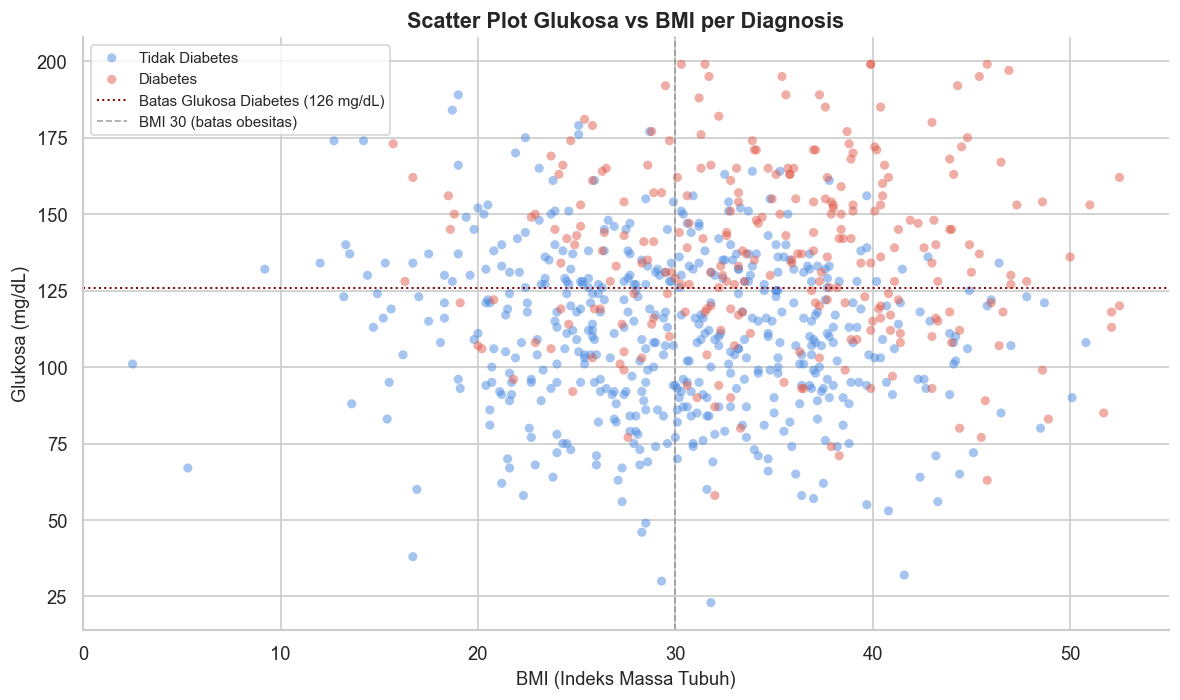

In [22]:
palet_diag = {'Tidak Diabetes': '#4C8BE0', 'Diabetes': '#E05C4C'}

plt.figure(figsize=(10, 6))

for diag, warna in palet_diag.items():
    subset = df_clean[df_clean['Diagnosis'] == diag]
    plt.scatter(
        subset['BMI'], subset['Glucose'],
        c=warna, label=diag, alpha=0.5, s=30, edgecolors='none'
    )

plt.axhline(126, color='darkred', linestyle=':', linewidth=1.2, label='Batas Glukosa Diabetes (126 mg/dL)')
plt.axvline(30,  color='gray',    linestyle='--', linewidth=1.0, alpha=0.7, label='BMI 30 (batas obesitas)')

plt.title('Scatter Plot Glukosa vs BMI per Diagnosis')
plt.xlabel('BMI (Indeks Massa Tubuh)')
plt.ylabel('Glukosa (mg/dL)')
plt.legend(fontsize=9)
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

Titik merah (Diabetes) terkonsentrasi di kuadran kanan atas, yaitu area dengan BMI di atas 30 dan glukosa di atas 126 mg/dL. Ini memperkuat bahwa kombinasi obesitas dan glukosa tinggi berkaitan erat dengan diagnosis diabetes. Namun ada juga pasien Diabetes dengan BMI rendah dan glukosa sangat tinggi, yang mengindikasikan faktor lain seperti genetik turut berperan. Sebaliknya, tidak semua pasien dengan BMI dan glukosa tinggi terdiagnosis diabetes, artinya tidak ada satu faktor tunggal yang cukup untuk menentukan diagnosis.

## Statistika Inferensial

### Uji Hipotesis 1 — Independent t-Test: Glukosa

H0: Rata-rata glukosa pasien Diabetes sama dengan rata-rata glukosa pasien Tidak Diabetes.

H1: Rata-rata glukosa pasien Diabetes berbeda secara signifikan dari pasien Tidak Diabetes.

Tingkat signifikansi: alpha = 0.05

In [23]:
g_td = df_clean[df_clean['Outcome'] == 0]['Glucose'].dropna()
g_d  = df_clean[df_clean['Outcome'] == 1]['Glucose'].dropna()

lev_stat, lev_p = stats.levene(g_td, g_d)
equal_var = lev_p > 0.05

t_stat, p_val = stats.ttest_ind(g_td, g_d, equal_var=equal_var)

print("Uji Levene (kesamaan varians):")
print(f"  statistic : {lev_stat:.4f}, p-value : {lev_p:.4f}, equal_var : {equal_var}")
print()
print("Independent t-Test: Glukosa")
print(f"  Mean Tidak Diabetes : {g_td.mean():.2f} mg/dL (std = {g_td.std():.2f})")
print(f"  Mean Diabetes       : {g_d.mean():.2f} mg/dL (std = {g_d.std():.2f})")
print(f"  t-statistic         : {t_stat:.4f}")
print(f"  p-value             : {p_val:.2e}")
print()
if p_val < 0.05:
    print("Keputusan: H0 ditolak")
else:
    print("Keputusan: H0 gagal ditolak")

Uji Levene (kesamaan varians):
  statistic : 2.2802, p-value : 0.1314, equal_var : True

Independent t-Test: Glukosa
  Mean Tidak Diabetes : 110.58 mg/dL (std = 26.70)
  Mean Diabetes       : 137.58 mg/dL (std = 28.75)
  t-statistic         : -13.0028
  p-value             : 4.51e-35

Keputusan: H0 ditolak


Uji Levene menghasilkan p = 0.1314, artinya varians kedua kelompok tidak berbeda signifikan sehingga digunakan equal variance assumed (equal_var = True).

Hasil uji t menghasilkan t = -13.0028 dengan p-value = 4.51e-35, jauh di bawah alpha 0.05. H0 ditolak. Terdapat perbedaan rata-rata glukosa yang sangat signifikan secara statistik antara pasien Diabetes (137.58 mg/dL, std = 28.75) dan Tidak Diabetes (110.58 mg/dL, std = 26.70). Selisih 27 mg/dL ini bukan kebetulan dan mencerminkan perbedaan fisiologis nyata antara kedua kelompok.

### Uji Hipotesis 2 — Independent t-Test: BMI

H0: Rata-rata BMI pasien Diabetes sama dengan rata-rata BMI pasien Tidak Diabetes.

H1: Rata-rata BMI pasien Diabetes berbeda secara signifikan dari pasien Tidak Diabetes.

Tingkat signifikansi: alpha = 0.05

In [24]:
b_td = df_clean[df_clean['Outcome'] == 0]['BMI'].dropna()
b_d  = df_clean[df_clean['Outcome'] == 1]['BMI'].dropna()

lev2_stat, lev2_p = stats.levene(b_td, b_d)
equal_var2 = lev2_p > 0.05

t2_stat, p2_val = stats.ttest_ind(b_td, b_d, equal_var=equal_var2)

print("Uji Levene (kesamaan varians):")
print(f"  statistic : {lev2_stat:.4f}, p-value : {lev2_p:.4f}, equal_var : {equal_var2}")
print()
print("Independent t-Test: BMI")
print(f"  Mean Tidak Diabetes : {b_td.mean():.2f} (std = {b_td.std():.2f})")
print(f"  Mean Diabetes       : {b_d.mean():.2f} (std = {b_d.std():.2f})")
print(f"  t-statistic         : {t2_stat:.4f}")
print(f"  p-value             : {p2_val:.2e}")
print()
if p2_val < 0.05:
    print("Keputusan: H0 ditolak")
else:
    print("Keputusan: H0 gagal ditolak")

Uji Levene (kesamaan varians):
  statistic : 0.0926, p-value : 0.7609, equal_var : True

Independent t-Test: BMI
  Mean Tidak Diabetes : 30.02 (std = 7.57)
  Mean Diabetes       : 35.18 (std = 7.56)
  t-statistic         : -9.0122
  p-value             : 1.59e-18

Keputusan: H0 ditolak


Uji Levene menghasilkan p = 0.7609, artinya varians kedua kelompok setara sehingga digunakan equal variance assumed (equal_var = True).

Hasil uji t menghasilkan t = -9.0122 dengan p-value = 1.59e-18. H0 ditolak. Rata-rata BMI pasien Diabetes (35.18, std = 7.56) secara signifikan lebih tinggi dibandingkan pasien Tidak Diabetes (30.02, std = 7.57). Perbedaan sekitar 5 poin BMI ini signifikan secara klinis dan statistik, mengonfirmasi obesitas sebagai faktor risiko nyata dalam dataset ini.

### Analisis Korelasi Pearson

In [25]:
kolom_korelasi = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

pearson_corr  = df_clean[kolom_korelasi].corr(method='pearson')['Outcome'].drop('Outcome')

df_pearson = pd.DataFrame({
    'Pearson r' : pearson_corr.round(4),
}).sort_values('Pearson r', key=abs, ascending=False)

print("Korelasi Pearson terhadap Outcome (Diagnosis):")
print(df_pearson.to_string())

Korelasi Pearson terhadap Outcome (Diagnosis):
                          Pearson r
Pregnancies                  0.5929
Glucose                      0.4252
BMI                          0.3096
BloodPressure               -0.0961
Age                          0.0682
DiabetesPedigreeFunction     0.0209


Kehamilan memiliki korelasi Pearson tertinggi terhadap Outcome (r = 0.5929), diikuti Glukosa (r = 0.4252) dan IMT (r = 0.3096). Tekanan Darah berkorelasi negatif sangat lemah (r = -0.0961), sedangkan Usia (r = 0.0682) dan DPF (r = 0.0209) hampir tidak berkorelasi.

Nilai korelasi yang jauh dari 1 pada semua pasangan menunjukkan tidak ada hubungan linear sempurna, sehingga diagnosis diabetes tidak bisa dijelaskan oleh satu variabel saja.

### Uji Chi-Square: Variabel Kategorikal vs Diagnosis

In [26]:
# BMI vs Diagnosis
ct_bmi = pd.crosstab(df_clean['Kategori_BMI'], df_clean['Outcome'],
                     rownames=['Kategori BMI'], colnames=['Outcome (0=Tidak, 1=Diabetes)'])
chi2_bmi, p_bmi, dof_bmi, _ = stats.chi2_contingency(ct_bmi)

print("=== Chi-Square: Kategori BMI vs Outcome ===")
print(ct_bmi)
print()
print(f"  chi2-statistic : {chi2_bmi:.4f}")
print(f"  p-value        : {p_bmi:.2e}")
print(f"  degrees of freedom : {dof_bmi}")
print()
if p_bmi < 0.05:
    print("Keputusan: Ada hubungan signifikan antara Kategori BMI dan Diagnosis")
else:
    print("Keputusan: Tidak ada hubungan signifikan")


#  Usia vs Diagnosis
ct_age = pd.crosstab(df_clean['Kelompok_Usia'], df_clean['Outcome'],
                     rownames=['Kelompok Usia'], colnames=['Outcome (0=Tidak, 1=Diabetes)'])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(ct_age)

print("=== Chi-Square: Kelompok Usia vs Outcome ===")
print(ct_age)
print()
print(f"  chi2-statistic : {chi2_age:.4f}")
print(f"  p-value        : {p_age:.2e}")
print(f"  degrees of freedom : {dof_age}")
print()
if p_age < 0.05:
    print("Keputusan: Ada hubungan signifikan antara Kelompok Usia dan Diagnosis")
else:
    print("Keputusan: Tidak ada hubungan signifikan antara Kelompok Usia dan Diagnosis")

=== Chi-Square: Kategori BMI vs Outcome ===
Outcome (0=Tidak, 1=Diabetes)    0    1
Kategori BMI                           
Gemuk                          120   40
Kurus                           29    3
Normal                          97   23
Obesitas                       254  202

  chi2-statistic : 46.8831
  p-value        : 3.68e-10
  degrees of freedom : 3

Keputusan: Ada hubungan signifikan antara Kategori BMI dan Diagnosis
=== Chi-Square: Kelompok Usia vs Outcome ===
Outcome (0=Tidak, 1=Diabetes)    0   1
Kelompok Usia                         
21-29                          202  97
30-39                          171  96
40-49                           97  50
50-59                           25  22
60+                              5   3

  chi2-statistic : 3.9348
  p-value        : 4.15e-01
  degrees of freedom : 4

Keputusan: Tidak ada hubungan signifikan antara Kelompok Usia dan Diagnosis


Uji Chi-Square Kategori BMI vs Diagnosis menghasilkan chi2 = 46.8831 dengan p = 3.68e-10 (dof = 3). Nilai p jauh di bawah 0.05, artinya ada hubungan yang signifikan secara statistik antara kategori BMI dan diagnosis. Distribusi kasus Diabetes tidak merata di semua kategori BMI: dari 456 pasien Obesitas, 202 (44.3%) terdiagnosis Diabetes, sementara dari 32 pasien Kurus hanya 3 (9.4%).

Uji Chi-Square Kelompok Usia vs Diagnosis menghasilkan chi2 = 3.9348 dengan p = 0.4149 (dof = 4). Nilai p di atas 0.05, artinya tidak ada hubungan yang signifikan secara statistik antara kelompok usia dan diagnosis. Hasil ini konsisten dengan temuan korelasi Pearson yang sangat lemah (r = 0.07). Perbedaan tingkat diabetes antar kelompok usia yang terlihat di grafik kemungkinan merupakan variasi sampel acak, bukan pola yang dapat digeneralisasi.

## Kesimpulan dan Rekomendasi


Dari analisis terhadap 768 pasien wanita Pima Indian, tidak semua variabel klinis memiliki kekuatan yang sama dalam membedakan pasien Diabetes dari yang Tidak Diabetes.

Pertama, Glukosa adalah indikator paling kuat dengan perbedaan rata-rata 27 mg/dL antara kedua kelompok (Diabetes: 137.58 mg/dL, Tidak Diabetes: 110.58 mg/dL). Uji t mengonfirmasi perbedaan ini sangat signifikan (t = -13.00, p = 4.51e-35) dan korelasinya terhadap diagnosis cukup tinggi (r = 0.43).

Kedua, BMI terbukti signifikan secara statistik maupun klinis. Pasien Diabetes rata-rata memiliki BMI 35.18 versus 30.02 pada pasien Tidak Diabetes (t = -9.01, p = 1.59e-18). Kelompok Obesitas memiliki tingkat diabetes 44.3%, hampir lima kali lipat dari kelompok Kurus yang hanya 9.4%. Uji Chi-Square juga mengonfirmasi hubungan antara kategori BMI dan diagnosis (chi2 = 46.88, p = 3.68e-10).

Ketiga, Usia dan Kelompok Usia tidak terbukti memiliki hubungan signifikan dengan diagnosis. Korelasi Pearson hanya 0.07 dan uji Chi-Square menghasilkan p = 0.4149, menunjukkan perbedaan yang terlihat di grafik kemungkinan merupakan variasi acak.

*Rekomendasi*

Skrining diabetes sebaiknya diprioritaskan pada wanita dengan kombinasi BMI di atas 30 dan glukosa di atas 100 mg/dL. Program pengendalian berat badan adalah intervensi dengan dampak paling luas mengingat 59.4% populasi dalam dataset masuk kategori obesitas. Pemantauan glukosa berkala pada pasien pradiabetes (100 hingga 126 mg/dL) perlu dilakukan untuk mencegah progresi ke diabetes. Dataset ini juga memiliki potensi untuk dikembangkan ke pemodelan prediksi dengan Glukosa dan BMI sebagai fitur utama.